# UNIVARIATE ANALYSIS

## Load the data
- Here I load the pickle file that was save in step1

In [12]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
df = pd.read_pickle('data_MPG_clean.pkl')

In [3]:
print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
291  19.203125          8           267         125    3605     15.000000   
51   30.000000          4            79          70    2074     19.500000   
6    14.000000          8           454         220    4354      9.000000   
15   22.000000          6           198          95    2833     15.500000   
192  22.000000          6           250         105    3353     14.500000   
350  34.687500          4           105          63    2215     14.898438   
69   12.000000          8           350         160    4456     13.500000   
70   13.000000          8           400         190    4422     12.500000   
27   11.000000          8           318         210    4382     13.500000   
33   19.000000          6           232         100    2634     13.000000   

     model_year  origin  
291          79     usa  
51           71  europe  
6            70     usa  
15           70     usa  
192          76     us

In [2]:
print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float16 
 1   cylinders     392 non-null    int8    
 2   displacement  392 non-null    int16   
 3   horsepower    392 non-null    int16   
 4   weight        392 non-null    int16   
 5   acceleration  392 non-null    float16 
 6   model_year    392 non-null    int8    
 7   origin        392 non-null    category
dtypes: category(1), float16(2), int16(3), int8(2)
memory usage: 8.2 KB
None


In [4]:
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.453125    5.471939    194.410714  104.469388  2977.584184   
std      7.804688    1.705783    104.645191   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.539062   75.979592  
std        2.757812    3.683737  
min        8.000000   70.000000  
25%       13.773438   73.000000  
50%       15.500000   76.000000  
75%       17.023438   79.000000  
max       24.796875   82.000000  


In [6]:
# lets see the stats on categporical column: origin
df['origin'].describe()

count     392
unique      3
top       usa
freq      245
Name: origin, dtype: object

In [7]:
df['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

## A) For Numerical Columns:

In [8]:
# identify numeric columns
numeric_df = df.select_dtypes(include=['number'])

print("numeric_df:\n",numeric_df.head(5))
print("\n\nnumeric columns:",numeric_df.columns)

numeric_df:
     mpg  cylinders  displacement  horsepower  weight  acceleration  model_year
0  18.0          8           307         130    3504          12.0          70
1  15.0          8           350         165    3693          11.5          70
2  18.0          8           318         150    3436          11.0          70
3  16.0          8           304         150    3433          12.0          70
4  17.0          8           302         140    3449          10.5          70


numeric columns: Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year'],
      dtype='object')


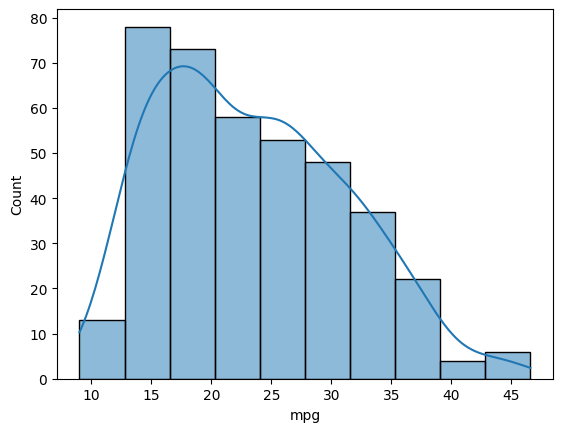

In [13]:
# step0: Plot histogram for 1 column: Age 

col = "mpg"
sns.histplot(df[col], bins=10, kde=True) # kde--> Kernel Density Estimation 
plt.show()

# Now lets prettify above

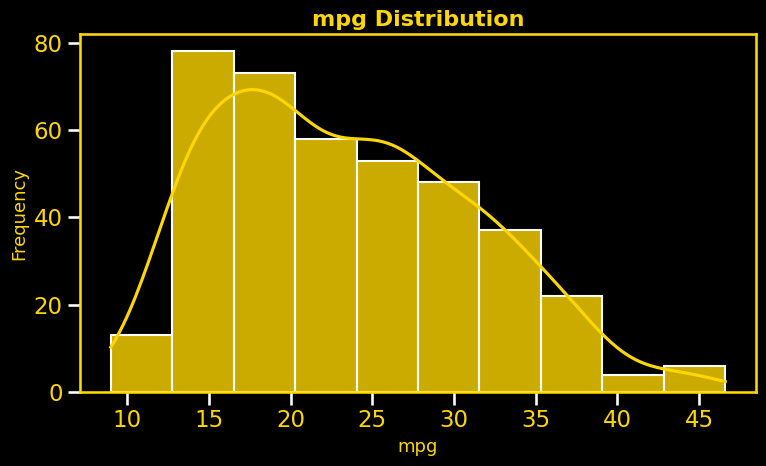

In [14]:
# step1: Prettify above. Plot histogram for 1 column: Age 

col = "mpg"

plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

plt.figure(figsize=(8,5))

sns.histplot(df[col], bins=10, kde=True, color='gold', edgecolor='white', alpha=0.8, )

# Titles and labels
plt.title(f"{col} Distribution", fontsize=16, color='gold', fontweight='bold')
plt.xlabel(col, fontsize=13, color='gold')
plt.ylabel("Frequency", fontsize=13, color='gold')

# Customize ticks and spines
plt.xticks(color='gold')
plt.yticks(color='gold')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('gold')

# Show plot
plt.tight_layout()
plt.show()

# Obser: Most of employees are in age range of 26 to 40

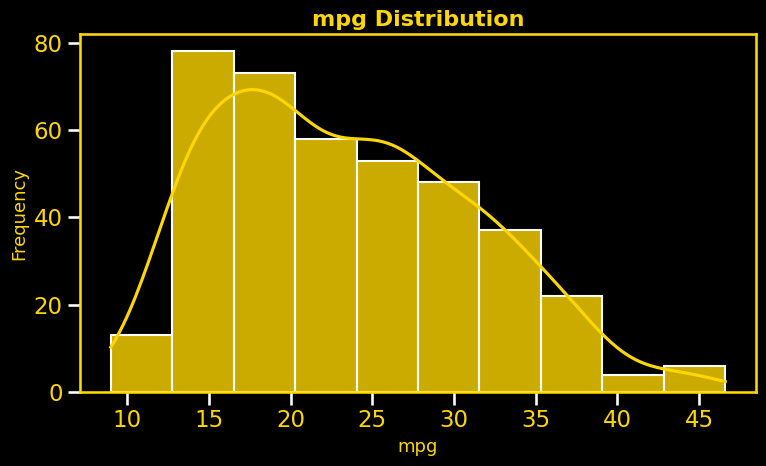

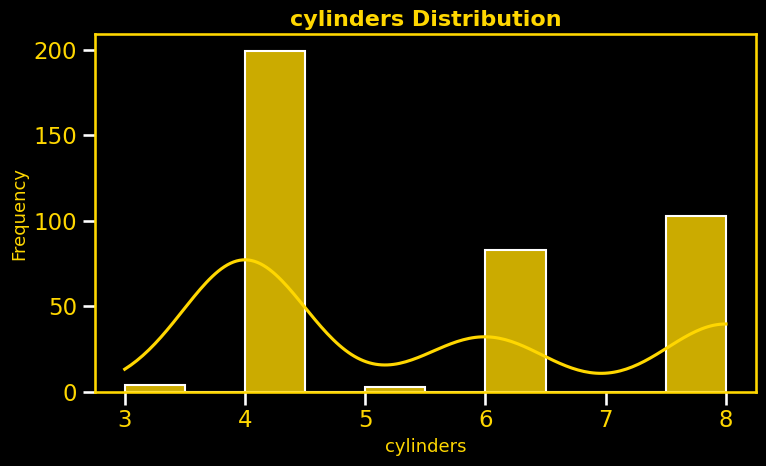

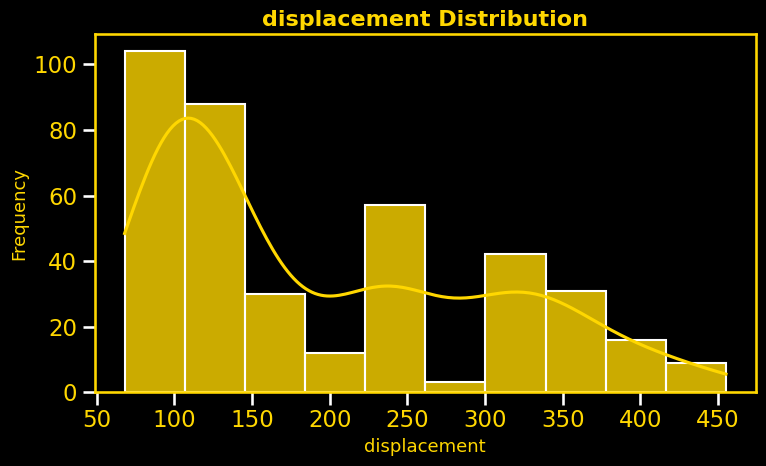

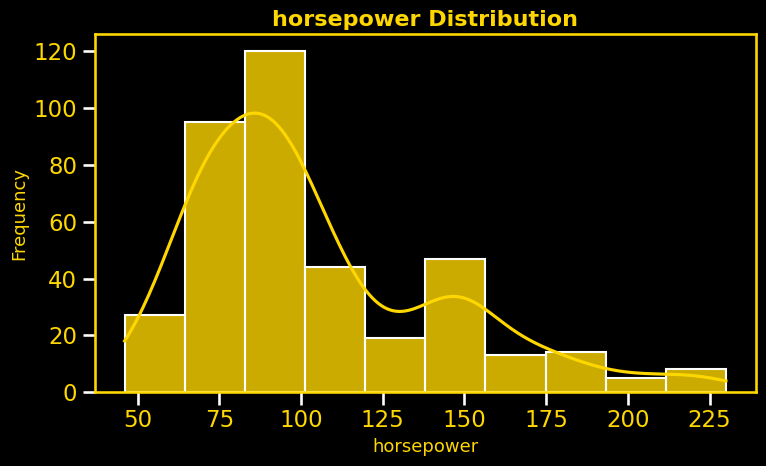

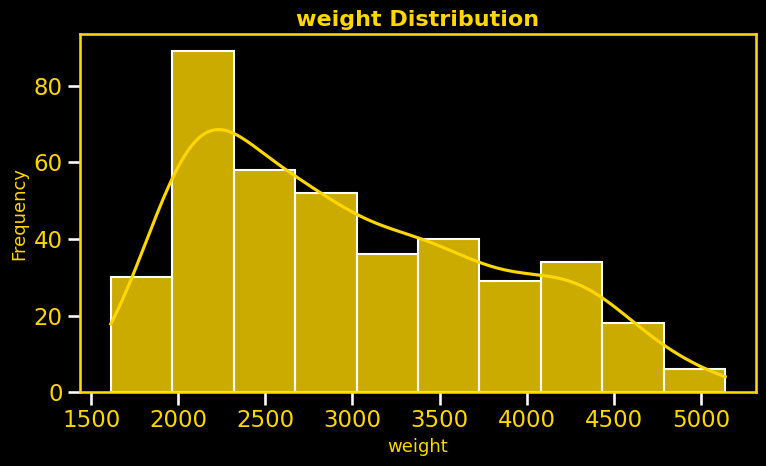

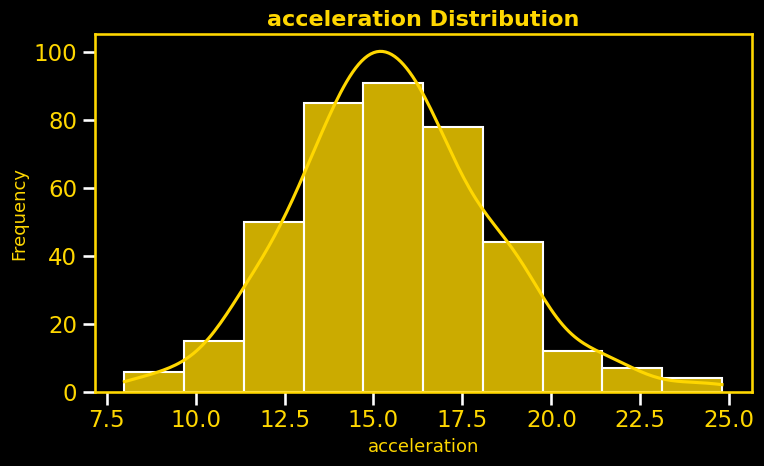

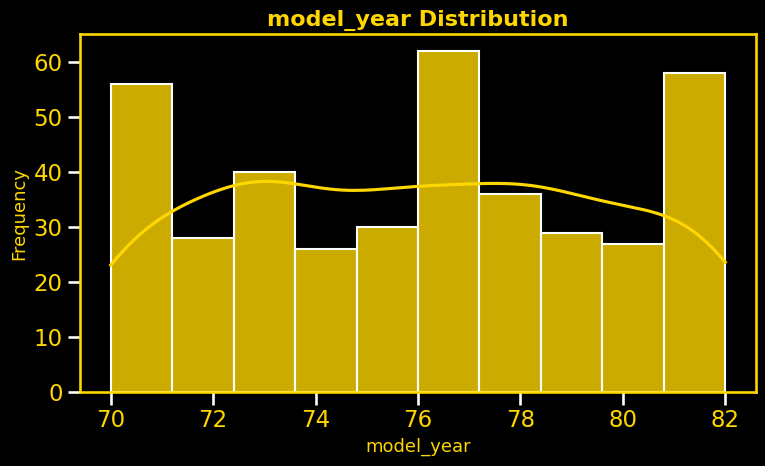

In [15]:
# step2: Now do this for rest of the columns

columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year'
          ]

for col in columns:
    
    plt.style.use("dark_background")  
    
    # Optional: control Seaborn palette and font scale
    sns.set_palette(["gold"])
    sns.set_context("talk")
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[col], bins=10, kde=True, color='gold', edgecolor='white', alpha=0.8)
    
    # Titles and labels
    plt.title(f"{col} Distribution", fontsize=16, color='gold', fontweight='bold')
    plt.xlabel(col, fontsize=13, color='gold')
    plt.ylabel("Frequency", fontsize=13, color='gold')
    
    # Customize ticks and spines
    plt.xticks(color='gold')
    plt.yticks(color='gold')
    for spine in plt.gca().spines.values():
        spine.set_edgecolor('gold')
    
    # Show plot
    plt.tight_layout()
    plt.show()

# observ: 

## Boxplot
Now I want to identify outliers and see the main  bulk of data lies

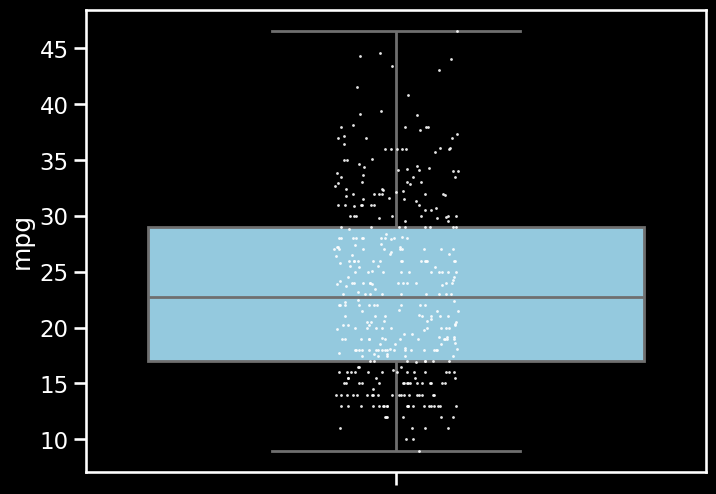

In [16]:
# step0: First do this for 1 columns

fig, ax = plt.subplots(figsize=(8, 6))
col = 'mpg'

sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
sns.stripplot(data=df, y=col, color='white', size=2, ax=ax, alpha=0.9)

plt.show()

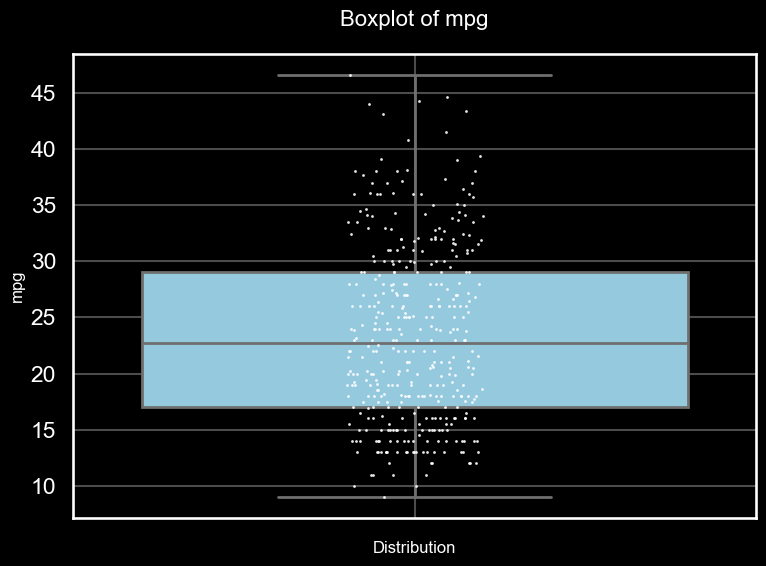

Q1 (25th percentile): 17.0
Q2 (Median, 50th percentile): 22.75
Q3 (75th percentile): 29.0
IQR (Q3 - Q1): 12.0
Outliers:
Series([], Name: mpg, dtype: float16)


In [17]:
# step1: Prettify.First do this for 1 columns

sns.set_style("dark")

fig, ax = plt.subplots(figsize=(8, 6))
col = 'mpg'

sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
sns.stripplot(data=df, y=col, color='white', size=2, ax=ax, alpha=0.9)

fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax.set_title(f'Boxplot of {col}', fontsize=16, color='white', pad=20)
ax.set_ylabel(col, fontsize=12, color='white')
ax.set_xlabel('Distribution', fontsize=12, color='white')
ax.grid(True, alpha=0.3, color='white')

# Make tick labels visible
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='x', colors='white')

plt.tight_layout()
plt.show()

################################################

# Calculate Q1, Q2, Q3, IQR
Q1 = df[col].quantile(0.25)
Q2 = df[col].quantile(0.5)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median, 50th percentile): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Q3 - Q1): {IQR}")

# Identify Outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

print(f"Outliers:\n{outliers}")

# Observ: 

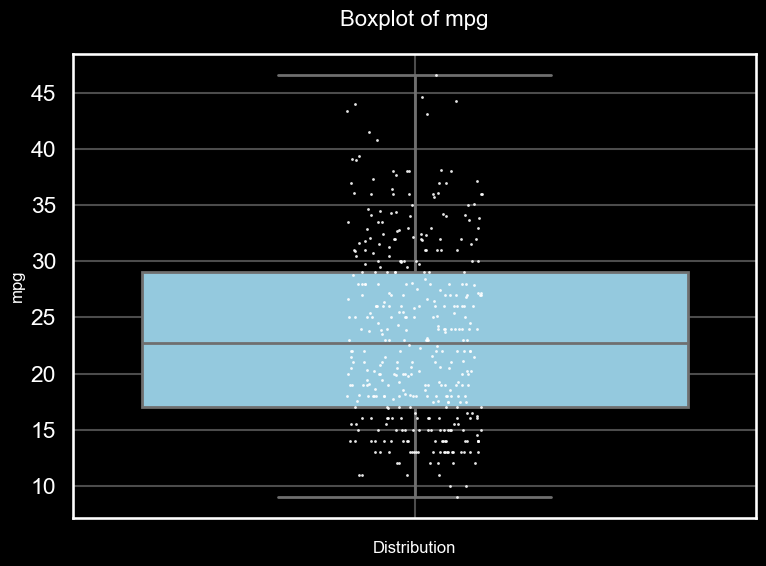

Q1 (25th percentile): 17.0
Q2 (Median, 50th percentile): 22.75
Q3 (75th percentile): 29.0
IQR (Q3 - Q1): 12.0
Outliers:
Series([], Name: mpg, dtype: float16)
+++++++++++++++++++++++++++++++




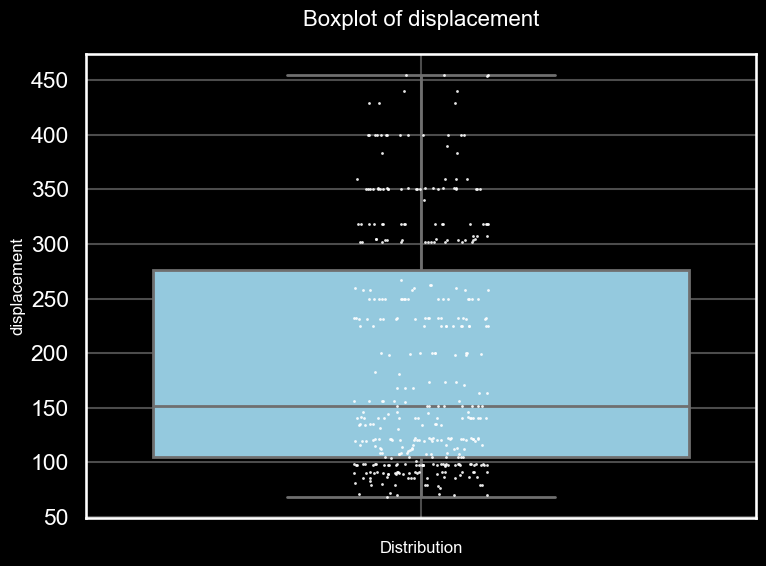

Q1 (25th percentile): 105.0
Q2 (Median, 50th percentile): 151.0
Q3 (75th percentile): 275.75
IQR (Q3 - Q1): 170.75
Outliers:
Series([], Name: displacement, dtype: int16)
+++++++++++++++++++++++++++++++




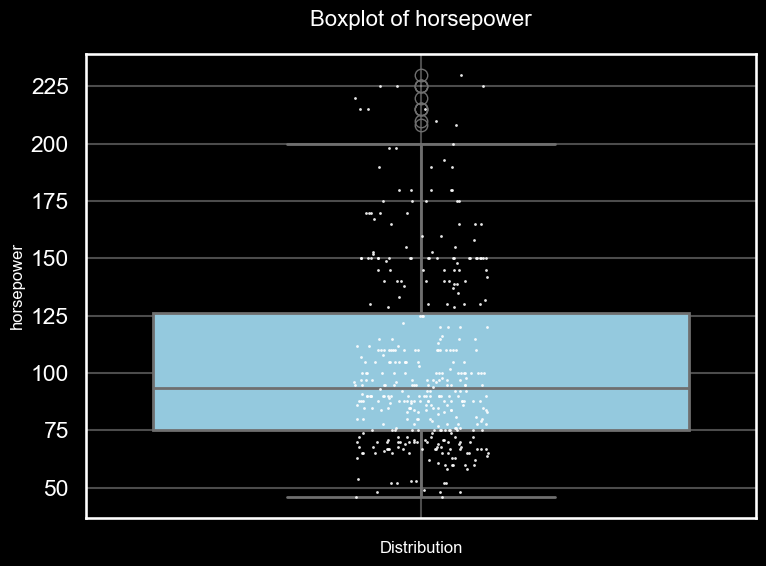

Q1 (25th percentile): 75.0
Q2 (Median, 50th percentile): 93.5
Q3 (75th percentile): 126.0
IQR (Q3 - Q1): 51.0
Outliers:
6      220
7      215
8      225
13     225
25     215
27     210
67     208
94     215
95     225
116    230
Name: horsepower, dtype: int16
+++++++++++++++++++++++++++++++




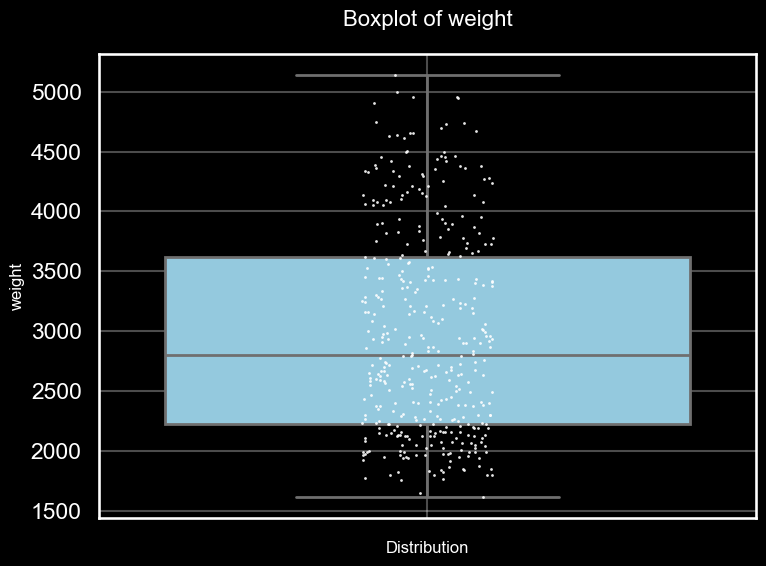

Q1 (25th percentile): 2225.25
Q2 (Median, 50th percentile): 2803.5
Q3 (75th percentile): 3614.75
IQR (Q3 - Q1): 1389.5
Outliers:
Series([], Name: weight, dtype: int16)
+++++++++++++++++++++++++++++++




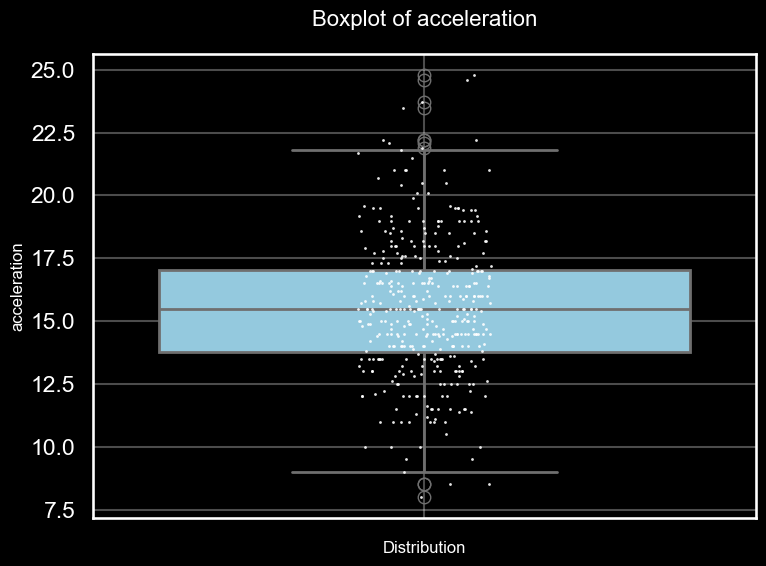

Q1 (25th percentile): 13.7734375
Q2 (Median, 50th percentile): 15.5
Q3 (75th percentile): 17.0234375
IQR (Q3 - Q1): 3.25
Outliers:
7       8.500000
9       8.500000
11      8.000000
59     23.500000
195    22.203125
196    22.093750
299    24.796875
300    22.203125
326    23.703125
394    24.593750
Name: acceleration, dtype: float16
+++++++++++++++++++++++++++++++




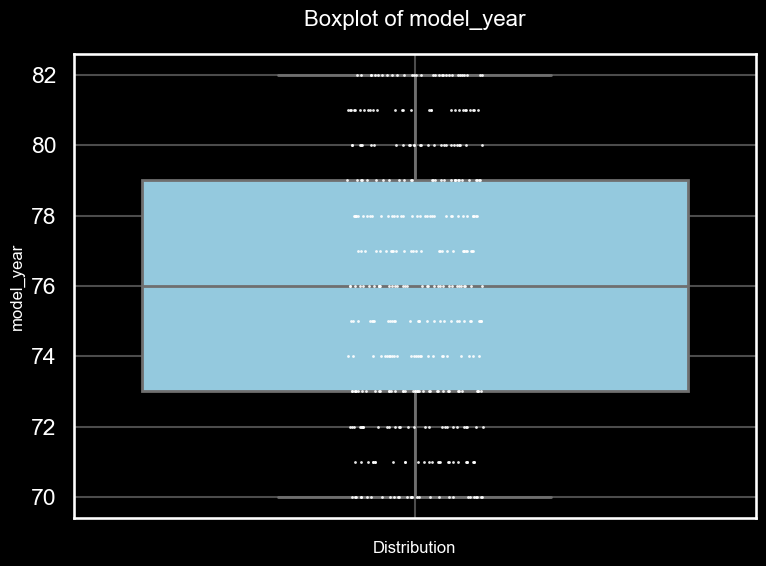

Q1 (25th percentile): 73.0
Q2 (Median, 50th percentile): 76.0
Q3 (75th percentile): 79.0
IQR (Q3 - Q1): 6.0
Outliers:
Series([], Name: model_year, dtype: int8)
+++++++++++++++++++++++++++++++




In [23]:
# step2: do this for all numeric columns, except 'cylinders',

columns = ['mpg', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year'
]

for col in columns:

    sns.set_style("dark")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
    sns.stripplot(data=df, y=col, color='white', size=2, ax=ax, alpha=0.9)
    
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    
    ax.set_title(f'Boxplot of {col}', fontsize=16, color='white', pad=20)
    ax.set_ylabel(col, fontsize=12, color='white')
    ax.set_xlabel('Distribution', fontsize=12, color='white')
    ax.grid(True, alpha=0.3, color='white')
    
    # Make tick labels visible
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='x', colors='white')
    
    plt.tight_layout()
    plt.show()

    # Calculate Q1, Q2, Q3, IQR
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.5)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"Q1 (25th percentile): {Q1}")
    print(f"Q2 (Median, 50th percentile): {Q2}")
    print(f"Q3 (75th percentile): {Q3}")
    print(f"IQR (Q3 - Q1): {IQR}")
    
    # Identify Outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"Outliers:\n{outliers}")
    print("+++++++++++++++++++++++++++++++\n\n")


In [ ]:
# KDE

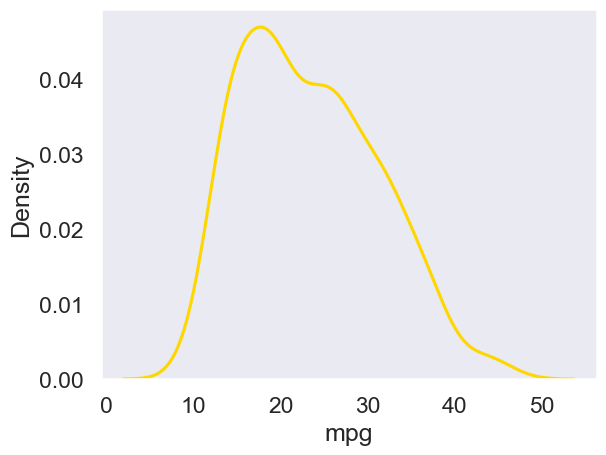

In [24]:
# step0: The basic simple KDE of Age
col = 'mpg'

sns.kdeplot(data=df, x=col)
plt.show()

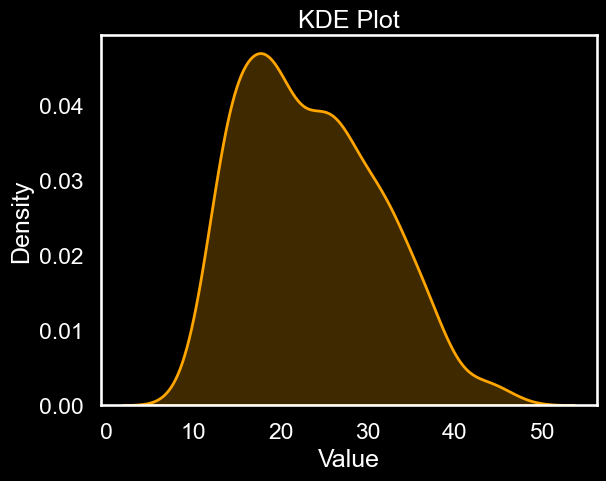

In [25]:
# step1: Now do KDE plot for column Age
plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

col = 'mpg'

sns.kdeplot(data=df, x=col, fill=True, color='orange', linewidth=2)

plt.title('KDE Plot')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

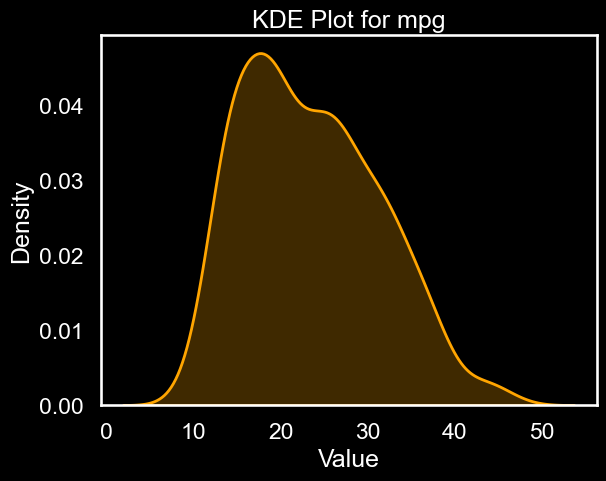

++++++++++++++++++++++



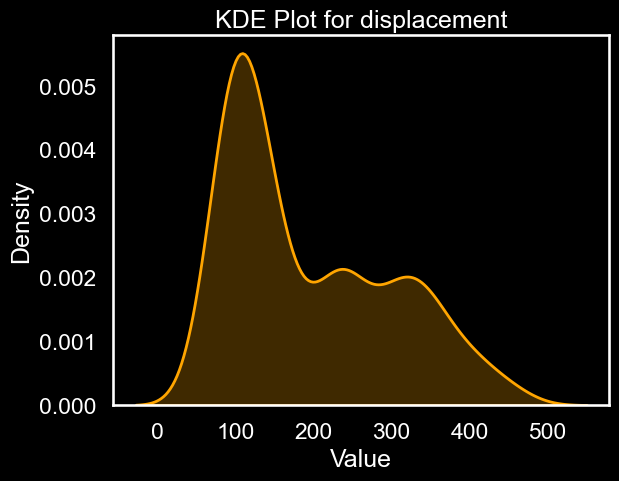

++++++++++++++++++++++



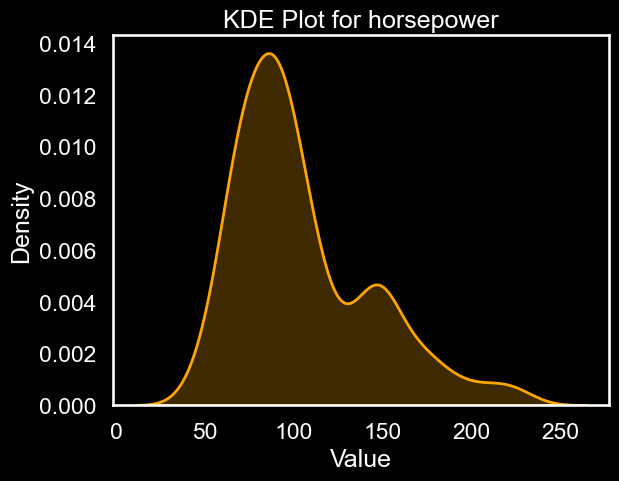

++++++++++++++++++++++



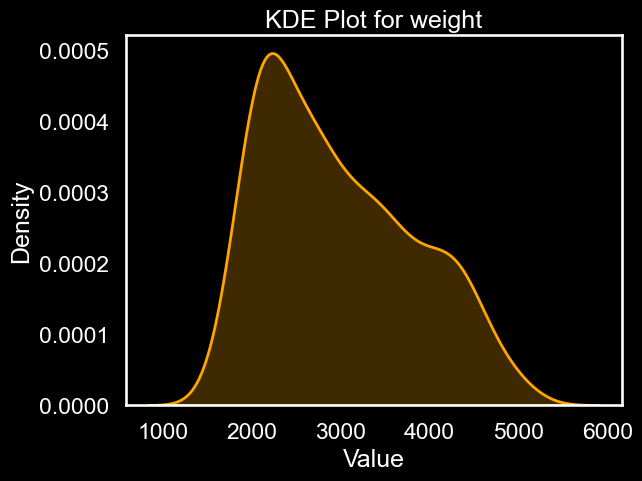

++++++++++++++++++++++



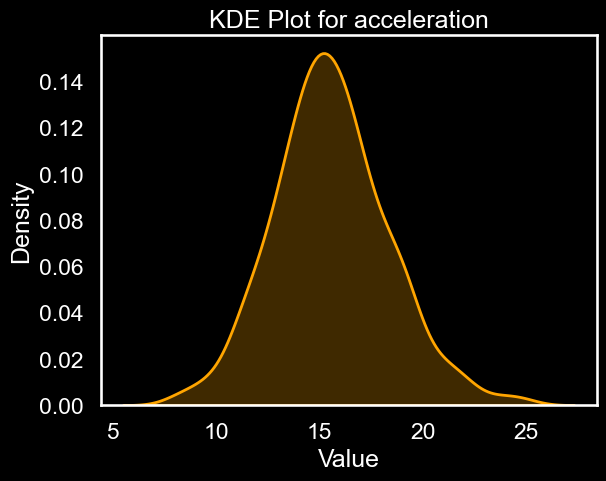

++++++++++++++++++++++



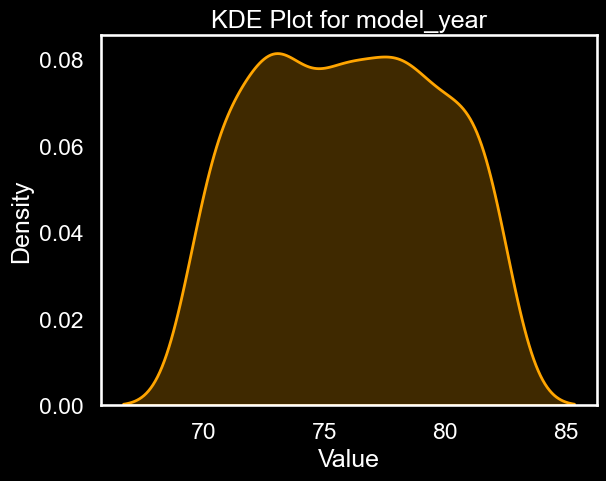

++++++++++++++++++++++



In [26]:
# step2: Now do KDE plot for all numeric columns
# Assuming df is your DataFrame and 'col' is the column of interest

plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

columns = ['mpg', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year'
]

for col in columns:
    sns.kdeplot(data=df, x=col, fill=True, color='orange', linewidth=2)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.show()
    print("++++++++++++++++++++++\n")


# Observ: 

## Barplot for categorical columns

In [27]:
# Lets print categorical columns
cat_cols = df.select_dtypes(include='category').columns.tolist()

print(cat_cols)

# Treat cylinders as category, although it is not of this type.

['origin']


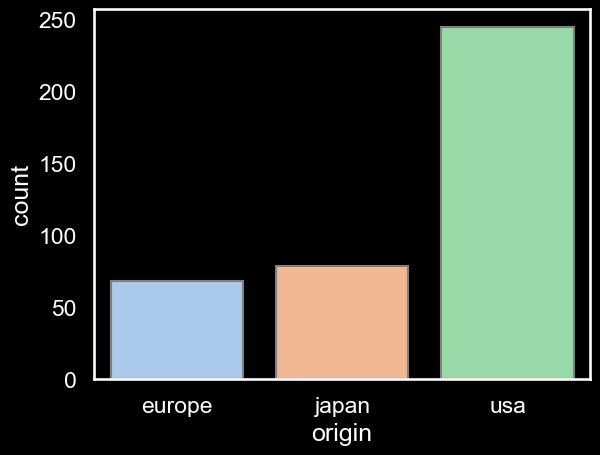

Category counts and percentages for 'origin':
   origin  Count  Percentage
0     usa    245   62.500000
1   japan     79   20.153061
2  europe     68   17.346939

---------------------------------------------



In [28]:
# step0: Do simple barplot for only one column

col = "origin"

ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.show()
##########################################

# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


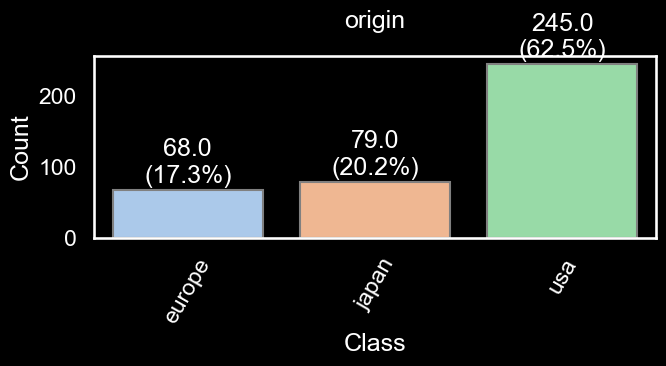

Category counts and percentages for 'origin':
   origin  Count  Percentage
0     usa    245   62.500000
1   japan     79   20.153061
2  europe     68   17.346939

---------------------------------------------



In [30]:
# step1: Prettify above barplot for only one column

col = "origin"

plt.figure(figsize=(7, 4))
ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.title(f'{col}', pad=20)  # add padding between title and plot
plt.xlabel('Class')
plt.ylabel('Count')

plt.xticks(rotation=60)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
    ax.annotate(f'{height}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2, height + 3),
                ha='center', va='bottom')

plt.tight_layout()  # adjust subplots to give some padding
plt.show()
#####################################


# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


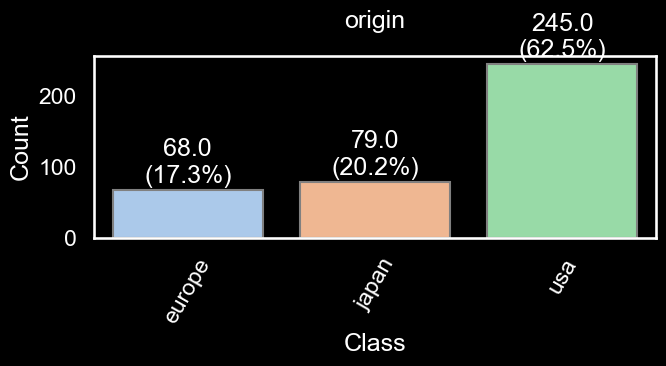

Category counts and percentages for 'origin':
   origin  Count  Percentage
0     usa    245   62.500000
1   japan     79   20.153061
2  europe     68   17.346939

---------------------------------------------



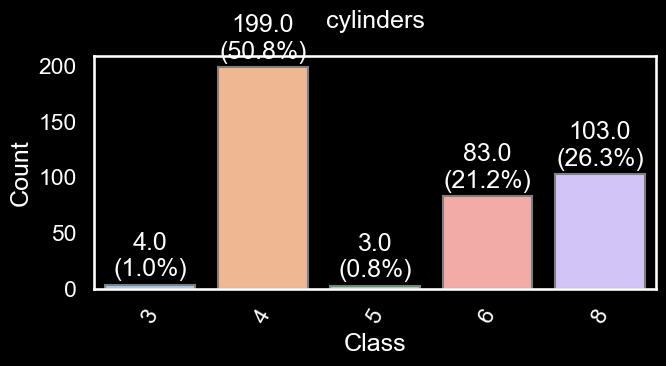

Category counts and percentages for 'cylinders':
   cylinders  Count  Percentage
0          4    199   50.765306
1          8    103   26.275510
2          6     83   21.173469
3          3      4    1.020408
4          5      3    0.765306

---------------------------------------------



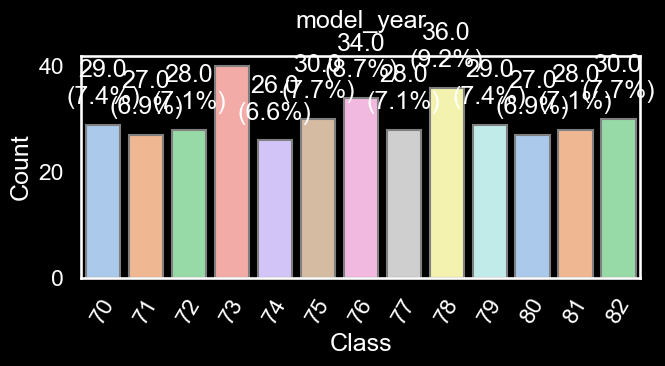

Category counts and percentages for 'model_year':
    model_year  Count  Percentage
0           73     40   10.204082
1           78     36    9.183673
2           76     34    8.673469
3           75     30    7.653061
4           82     30    7.653061
5           70     29    7.397959
6           79     29    7.397959
7           72     28    7.142857
8           77     28    7.142857
9           81     28    7.142857
10          71     27    6.887755
11          80     27    6.887755
12          74     26    6.632653

---------------------------------------------



In [32]:
# step2: Now do this for all columns using for loop

# columns = df.select_dtypes(include='category').columns.tolist()
columns = ['origin', 'cylinders', 'model_year']

for col in columns:
        
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
    plt.title(f'{col}', pad=20)  # add padding between title and plot
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=60)

    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        percentage = 100 * height / total
        # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
        ax.annotate(f'{height}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2, height + 3),
                    ha='center', va='bottom')
    
    plt.tight_layout()  # adjust subplots to give some padding
    plt.show()

    # Compute the data to print
    count_data = df[col].value_counts().reset_index()
    count_data.columns = [col, 'Count']
    count_data['Percentage'] = 100 * count_data['Count'] / len(df)
    
    # Print the data
    print(f"Category counts and percentages for '{col}':")
    print(count_data)
    print("\n---------------------------------------------\n")


In [33]:
# step3: The above graph looks all jumbled/overlapping: Solution plot each one seperately or work with raw numbers

# Counts of unique values
col = "origin"
counts = df[col].value_counts()
percentages = df[col].value_counts(normalize=True).mul(100).round(1)

freq_table = pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage (%)'])

print(freq_table)

        Count  Percentage (%)
origin                       
usa       245            62.5
japan      79            20.2
europe     68            17.3


In [34]:
# step4: Now put above in for loop

# columns = df.select_dtypes(include='category').columns.tolist()
columns = ['origin', 'cylinders', 'model_year']

for col in  columns:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True).mul(100).round(1)
    
    freq_table = pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage (%)'])
    
    print(freq_table)
    print("+++++++++\n\n")

# Observ: The column Over18 has all values True. It can be safely dropped

        Count  Percentage (%)
origin                       
usa       245            62.5
japan      79            20.2
europe     68            17.3
+++++++++


           Count  Percentage (%)
cylinders                       
4            199            50.8
8            103            26.3
6             83            21.2
3              4             1.0
5              3             0.8
+++++++++


            Count  Percentage (%)
model_year                       
73             40            10.2
78             36             9.2
76             34             8.7
75             30             7.7
82             30             7.7
70             29             7.4
79             29             7.4
72             28             7.1
77             28             7.1
81             28             7.1
71             27             6.9
80             27             6.9
74             26             6.6
+++++++++


